In [1]:
!pip install clip torch torchvision Pillow matplotlib scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=5d2fc2f0cb1602c51a48506fed908e4dcb53100a9b88ffe474edad8b84bfd32b
  Stored in direc

# CLIP

Imagen: arquitectura/barroco/barroco2.jpg
Probabilidades: {'Gothic architecture': np.float32(0.051286988), 'Baroque architecture': np.float32(0.94871306)}
Imagen: arquitectura/barroco/barroco.jpg
Probabilidades: {'Gothic architecture': np.float32(0.14965077), 'Baroque architecture': np.float32(0.85034925)}
Imagen: arquitectura/barroco/barroco3.jpg
Probabilidades: {'Gothic architecture': np.float32(0.25083), 'Baroque architecture': np.float32(0.74917)}
Imagen: arquitectura/barroco/barroco4.jpg
Probabilidades: {'Gothic architecture': np.float32(0.06947464), 'Baroque architecture': np.float32(0.93052536)}
Imagen: arquitectura/gotico/gotico4.jpg
Probabilidades: {'Gothic architecture': np.float32(0.99776196), 'Baroque architecture': np.float32(0.002237967)}
Imagen: arquitectura/gotico/gotico3.jpg
Probabilidades: {'Gothic architecture': np.float32(0.9536125), 'Baroque architecture': np.float32(0.046387486)}
Imagen: arquitectura/gotico/gotico.jpg
Probabilidades: {'Gothic architecture': np.flo

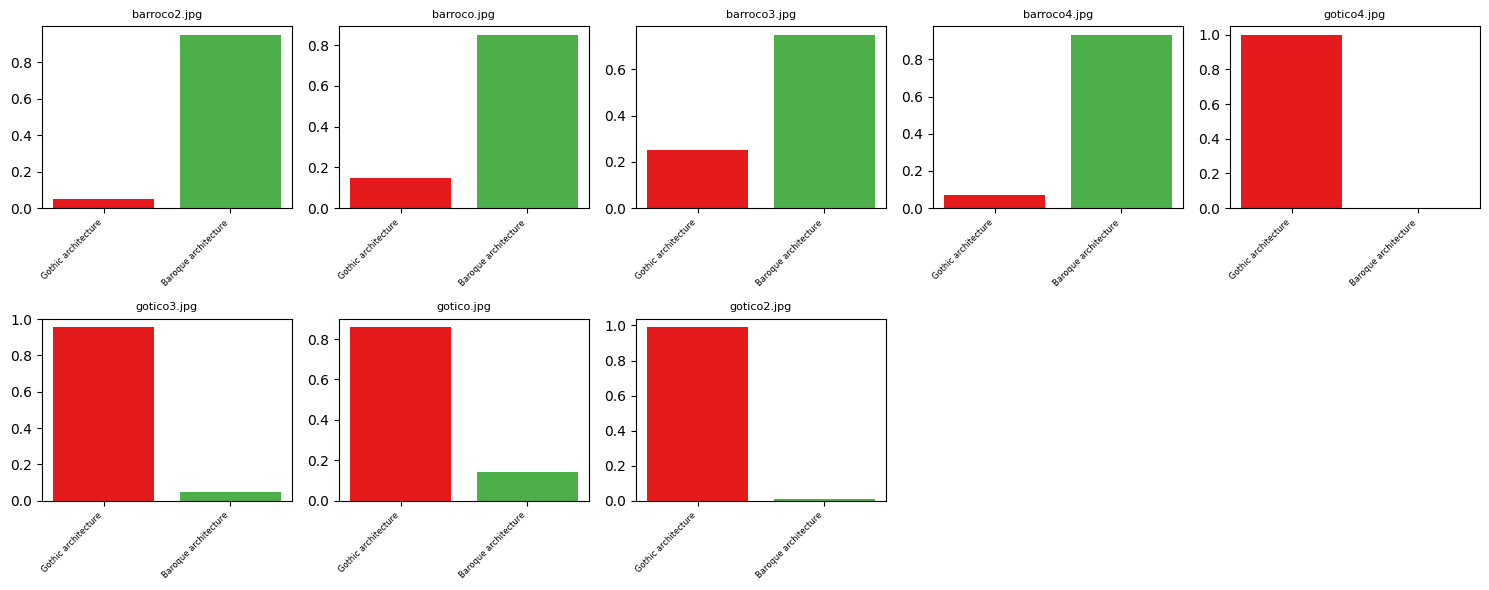

In [18]:
import open_clip
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuración del dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
model.to(device).eval()

# Definir clases y descripciones para arquitectura
classes = [
    "Gothic architecture",
    "Baroque architecture"
]
text_inputs = open_clip.tokenize(classes).to(device)

# Directorios de las imágenes
image_dir = "arquitectura/"
class_dirs = ["barroco", "gotico"]
image_files = []

# Cargar imágenes
for class_dir in class_dirs:
    class_path = os.path.join(image_dir, class_dir)
    if not os.path.exists(class_path):
        print(f"Error: Directorio no encontrado: {class_path}")
        continue
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_files.append(os.path.join(class_path, img_name))

# Verificar si hay imágenes
if not image_files:
    print(f"Error: No se encontraron imágenes en {image_dir}.")
    exit()

# Procesar imágenes y calcular probabilidades
probs_list = []
image_names = []
for img_path in image_files:
    try:
        image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text_inputs)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            logit_scale = model.logit_scale.exp()
            logits_per_image = (image_features @ text_features.T) * logit_scale
            probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
        probs_list.append(probs)
        image_names.append(os.path.basename(img_path))
        print(f"Imagen: {img_path}")
        print(f"Probabilidades: {dict(zip(classes, probs))}")
    except Exception as e:
        print(f"Error procesando {img_path}: {e}")

# Visualizar resultados
if probs_list:
    n_images = len(probs_list)
    cols = min(5, n_images)
    rows = (n_images + cols - 1) // cols
    plt.figure(figsize=(15, 3 * rows))
    for i, (probs, img_name) in enumerate(zip(probs_list, image_names)):
        plt.subplot(rows, cols, i + 1)
        plt.bar(classes, probs, color=['#e41a1c', '#4daf4a'])
        plt.title(img_name, fontsize=8)
        plt.xticks(rotation=45, ha="right", fontsize=6)
    plt.tight_layout()
    os.makedirs("resultados", exist_ok=True)
    plt.savefig("resultados/clip_confidence_plot.png")
    plt.show()
else:
    print("No hay resultados para visualizar.")

# TRADICIONAL

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precisión general del SVM: 1.00

Resultados de clasificación individual del SVM:
Imagen: barroco2.jpg -> Predicción: barroco (Real: barroco) - Correcto
Imagen: barroco.jpg -> Predicción: barroco (Real: barroco) - Correcto
Imagen: barroco3.jpg -> Predicción: barroco (Real: barroco) - Correcto
Imagen: barroco4.jpg -> Predicción: barroco (Real: barroco) - Correcto
Imagen: gotico4.jpg -> Predicción: gotico (Real: gotico) - Correcto
Imagen: gotico3.jpg -> Predicción: gotico (Real: gotico) - Correcto
Imagen: gotico.jpg -> Predicción: gotico (Real: gotico) - Correcto
Imagen: gotico2.jpg -> Predicción: gotico (Real: gotico) - Correcto


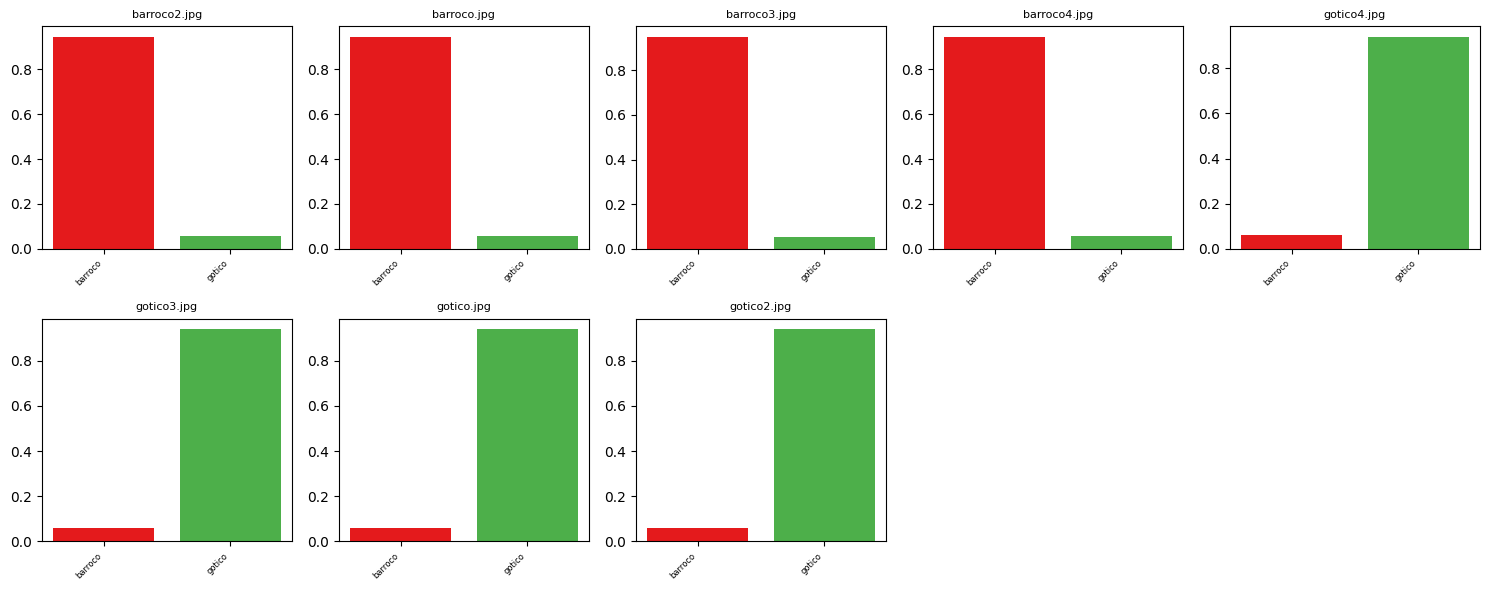

In [19]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os

# Configuración del modelo ResNet
device = "cuda" if torch.cuda.is_available() else "cpu"
resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet.eval().to(device)

# Transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Directorios de las imágenes
image_dir = "arquitectura/"
classes = ["barroco", "gotico"]
image_files = []
X, y = [], []

# Cargar imágenes y extraer características
for label, class_name in enumerate(classes):
    class_path = os.path.join(image_dir, class_name)
    if not os.path.exists(class_path):
        print(f"Error: Directorio no encontrado: {class_path}")
        continue
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    features = resnet(img_tensor).cpu().numpy().flatten()
                X.append(features)
                y.append(label)
                image_files.append(img_path)
            except Exception as e:
                print(f"Error procesando {img_path}: {e}")

X, y = np.array(X), np.array(y)
if X.shape[0] == 0:
    print("Error: No se extrajeron características de las imágenes.")
    exit()

# Entrenar SVM
svm = SVC(kernel="linear", probability=True)
svm.fit(X, y)

# Evaluar precisión
y_pred = svm.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Precisión general del SVM: {accuracy:.2f}\n")

# Mostrar resultados individuales
if len(image_files) == len(y_pred):
    print("Resultados de clasificación individual del SVM:")
    for i, img_path in enumerate(image_files):
        predicted_class = classes[y_pred[i]]
        actual_class = classes[y[i]]
        correct = "Correcto" if y_pred[i] == y[i] else "Incorrecto"
        print(f"Imagen: {os.path.basename(img_path)} -> Predicción: {predicted_class} (Real: {actual_class}) - {correct}")

# Visualizar probabilidades
if hasattr(svm, "predict_proba"):
    y_prob = svm.predict_proba(X)
    if len(image_files) == len(y_prob):
        n_images = len(y_prob)
        cols = min(5, n_images)
        rows = (n_images + cols - 1) // cols
        plt.figure(figsize=(15, 3 * rows))
        for i, prob in enumerate(y_prob):
            plt.subplot(rows, cols, i + 1)
            plt.bar(classes, prob, color=['#e41a1c', '#4daf4a'])
            plt.title(os.path.basename(image_files[i]), fontsize=8)
            plt.xticks(rotation=45, ha="right", fontsize=6)
        plt.tight_layout()
        os.makedirs("resultados", exist_ok=True)
        plt.savefig("resultados/svm_confidence_plot.png")
        plt.show()
    else:
        print("Error: El número de archivos de imagen no coincide con las probabilidades del SVM.")
else:
    print("Error: El modelo SVM no está configurado para calcular probabilidades.")